# Notebook 8 - Conformal Prediction

Adding proper uncertainty intervals around the predictions. This is the uncertainty quantification chapter for the dissertation.

Method: split conformal prediction
- use first half of test predictions to calibrate the interval width
- apply to second half and check actual coverage

Should give us a 90% prediction interval that's actually 90% (or close to it).
Runs on CPU.

TODO: maybe also try cqr (conformalized quantile regression) later

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT, 'processed')
PLOTS = os.path.join(ROOT, 'plots')
os.makedirs(PLOTS, exist_ok=True)

In [2]:
# pick which model to calibrate - usually the best one from notebook 6
MODEL = 'tft'   # change to whichever model won, options: lstm, tft, nhits, deepar, ensemble_weighted
ALPHA = 0.10    # 90% prediction interval (1 - alpha)

preds = np.load(os.path.join(PROC, MODEL + '_preds.npy'))
actuals = np.load(os.path.join(PROC, MODEL + '_actuals.npy'))

print('model:', MODEL)
print('preds shape:', preds.shape)
print('actuals shape:', actuals.shape)

model: tft
preds shape: (66710, 24)
actuals shape: (66710, 24)


## Split into calibration + test

In [3]:
n = preds.shape[0]
split = n // 2

p_cal, a_cal = preds[:split], actuals[:split]
p_tst, a_tst = preds[split:], actuals[split:]

print('calibration:', p_cal.shape[0])
print('test:       ', p_tst.shape[0])

calibration: 33355
test:        33355


In [4]:
# absolute residuals from calibration set
residuals = np.abs(a_cal - p_cal).flatten()
residuals = residuals[np.isfinite(residuals)]
print('residuals:', len(residuals))

# conformal quantile - this is the magic number for interval width
n_cal = len(residuals)
q_level = np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal
q_level = min(q_level, 1.0)
q_hat = np.quantile(residuals, q_level)

print('q_hat (90% quantile):', round(q_hat, 4), 'C')

residuals: 799968
q_hat (90% quantile): 3.6743 C


## Build intervals on test set

In [5]:
lower = p_tst - q_hat
upper = p_tst + q_hat

# check coverage
covered = (a_tst >= lower) & (a_tst <= upper)
finite = np.isfinite(a_tst) & np.isfinite(p_tst)

coverage = covered[finite].mean()
avg_width = (upper - lower)[finite].mean()

print('target coverage:', (1-ALPHA)*100, '%')
print('actual coverage:', round(coverage*100, 2), '%')
print('avg width:      ', round(avg_width, 4), 'C')

pf = p_tst.flatten()
af = a_tst.flatten()
m = np.isfinite(pf) & np.isfinite(af)
test_mae = mean_absolute_error(af[m], pf[m])
print('test MAE:       ', round(test_mae, 4))

target coverage: 90.0 %
actual coverage: 93.21 %
avg width:       7.3487 C
test MAE:        1.4072


## Coverage per horizon
Want to check if coverage stays good across all 24 forecast hours

In [6]:
H = preds.shape[1] if preds.ndim > 1 else 1
horizon_stats = []

for h in range(H):
    pt, at = p_tst[:, h], a_tst[:, h]
    lo, hi = pt - q_hat, pt + q_hat
    fin = np.isfinite(at) & np.isfinite(pt)
    cov = ((at >= lo) & (at <= hi)) & fin
    horizon_stats.append({
        'horizon': h+1,
        'coverage_pct': 100 * cov.sum() / fin.sum(),
        'avg_width': float((hi - lo)[fin].mean()),
        'mae': mean_absolute_error(at[fin], pt[fin]),
    })

hd = pd.DataFrame(horizon_stats)
print(hd.to_string(index=False))
hd.to_csv(os.path.join(PROC, 'conformal_' + MODEL + '_per_horizon.csv'), index=False)

 horizon  coverage_pct  avg_width      mae
       1     99.823115    7.34866 0.604337
       2     99.655141    7.34866 0.695102
       3     99.292120    7.34866 0.795853
       4     98.667907    7.34866 0.908231
       5     97.896348    7.34866 1.010452
       6     97.178448    7.34866 1.102072
       7     96.475215    7.34866 1.187373
       8     95.762636    7.34866 1.261083
       9     94.941576    7.34866 1.326824
      10     94.240303    7.34866 1.382987
      11     93.538693    7.34866 1.433875
      12     92.905883    7.34866 1.482383
      13     92.290809    7.34866 1.530161
      14     91.894981    7.34866 1.575684
      15     91.378636    7.34866 1.615808
      16     90.807883    7.34866 1.648059
      17     90.197731    7.34866 1.682139
      18     89.770914    7.34866 1.714304
      19     89.337870    7.34866 1.742087
      20     88.955817    7.34866 1.769541
      21     88.492243    7.34866 1.794585
      22     88.130895    7.34866 1.818064
      23   

## Plot some example forecasts with intervals

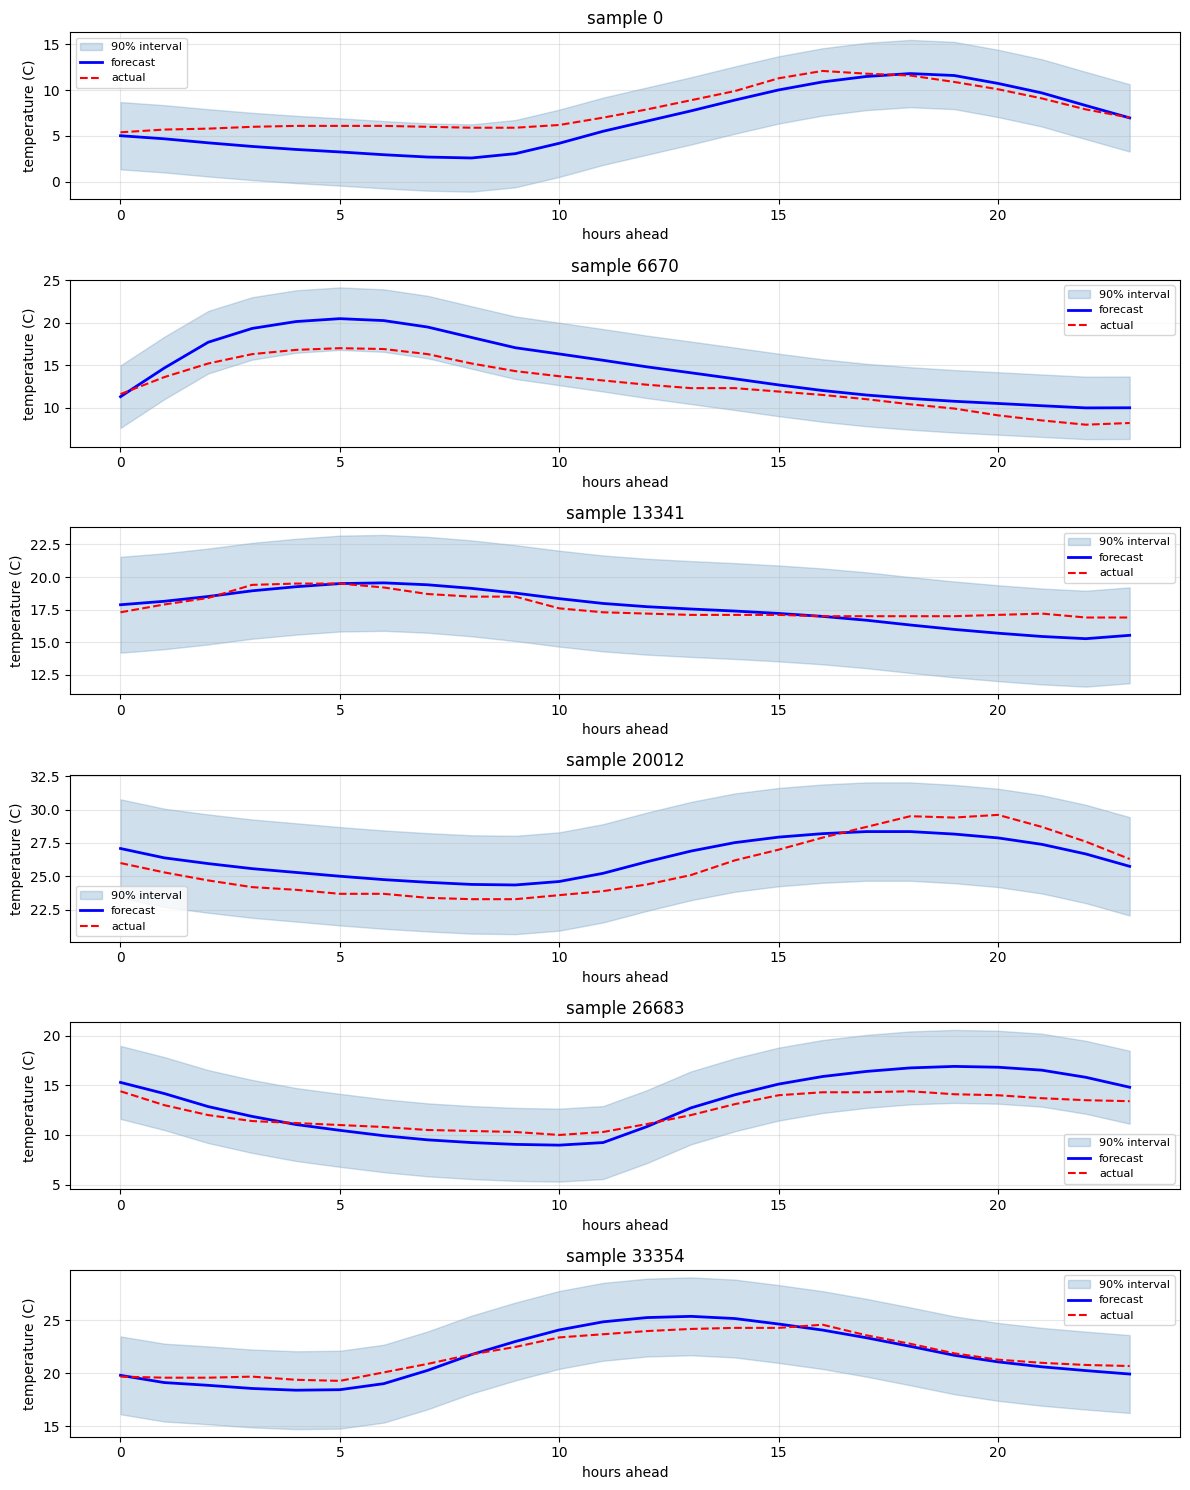

In [7]:
n_plot = 6
idx = np.linspace(0, p_tst.shape[0]-1, n_plot).astype(int)

fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.5*n_plot))
for ax, i in zip(axes, idx):
    h = np.arange(H)
    ax.fill_between(h, lower[i], upper[i], alpha=0.25, color='steelblue', label='90% interval')
    ax.plot(h, p_tst[i], color='blue', lw=2, label='forecast')
    ax.plot(h, a_tst[i], color='red', lw=1.5, linestyle='--', label='actual')
    ax.set_xlabel('hours ahead')
    ax.set_ylabel('temperature (C)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_title('sample ' + str(i))

plt.tight_layout()
plt.savefig(os.path.join(PLOTS, 'conformal_' + MODEL + '_intervals.png'), dpi=150)
plt.show()

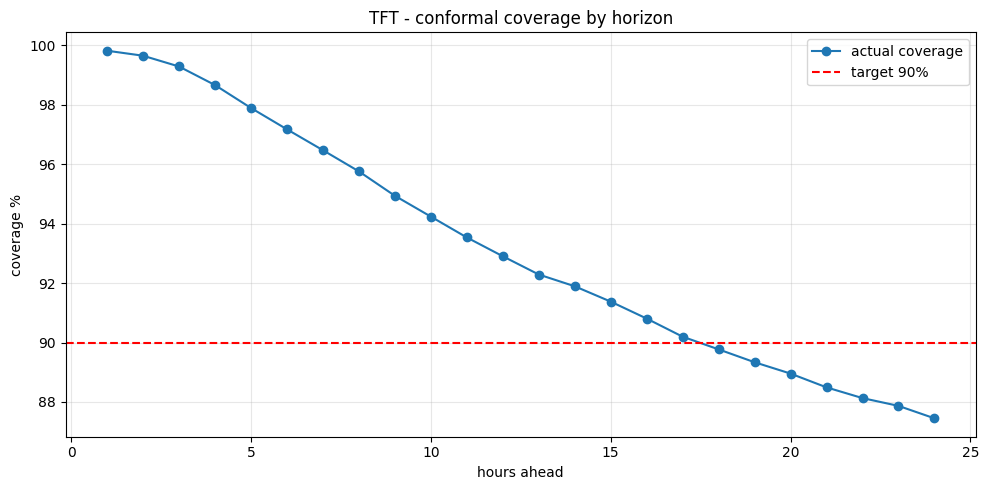

{'model': 'tft', 'alpha': 0.1, 'target_coverage': 0.9, 'empirical_coverage': np.float64(0.9321), 'avg_width': np.float64(7.3487), 'q_hat': np.float64(3.6743), 'test_mae': 1.4072}


In [8]:
# coverage vs horizon
plt.figure(figsize=(10, 5))
plt.plot(hd['horizon'], hd['coverage_pct'], marker='o', label='actual coverage')
plt.axhline(100*(1-ALPHA), color='red', linestyle='--', label='target ' + str(int((1-ALPHA)*100)) + '%')
plt.xlabel('hours ahead')
plt.ylabel('coverage %')
plt.title(MODEL.upper() + ' - conformal coverage by horizon')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, 'conformal_' + MODEL + '_coverage.png'), dpi=150)
plt.show()

# save summary
summary = {
    'model': MODEL,
    'alpha': ALPHA,
    'target_coverage': 1-ALPHA,
    'empirical_coverage': round(coverage, 4),
    'avg_width': round(avg_width, 4),
    'q_hat': round(q_hat, 4),
    'test_mae': round(test_mae, 4),
}
pd.DataFrame([summary]).to_csv(os.path.join(PROC, 'conformal_' + MODEL + '_summary.csv'), index=False)
print(summary)

## Per-horizon calibration

Problem with the single q_hat above - coverage is 99.8% at hour 1 but drops to about 87% at hour 24. One global width overcovers the easy short horizons and undercovers the hard long ones.

Fix: compute a separate q_hat for each of the 24 horizons from the calibration residuals. Same conformal idea, just done per horizon so the interval grows with lead time like it should.

In [9]:
# one q_hat per horizon
q_hats = np.zeros(H)
for h in range(H):
    res_h = np.abs(a_cal[:, h] - p_cal[:, h])
    res_h = res_h[np.isfinite(res_h)]
    nh = len(res_h)
    ql = min(np.ceil((nh + 1) * (1 - ALPHA)) / nh, 1.0)
    q_hats[h] = np.quantile(res_h, ql)

print('q_hat range:', round(q_hats.min(), 3), 'to', round(q_hats.max(), 3))
print(np.round(q_hats, 3))

q_hat range: 1.259 to 4.811
[1.259 1.548 1.844 2.153 2.422 2.659 2.859 3.046 3.208 3.358 3.501 3.65
 3.78  3.909 4.02  4.134 4.232 4.32  4.405 4.5   4.575 4.657 4.745 4.811]


In [10]:
lower2 = p_tst - q_hats   # broadcasts over rows
upper2 = p_tst + q_hats

stats2 = []
for h in range(H):
    pt, at = p_tst[:, h], a_tst[:, h]
    fin = np.isfinite(at) & np.isfinite(pt)
    cov = ((at >= lower2[:, h]) & (at <= upper2[:, h])) & fin
    stats2.append({
        'horizon': h+1,
        'q_hat': round(float(q_hats[h]), 4),
        'coverage_pct': 100 * cov.sum() / fin.sum(),
        'avg_width': round(float(2*q_hats[h]), 4),
    })

hd2 = pd.DataFrame(stats2)
print(hd2.to_string(index=False))

fin_all = np.isfinite(a_tst) & np.isfinite(p_tst)
cov_all = ((a_tst >= lower2) & (a_tst <= upper2))[fin_all].mean()
width_all = (upper2 - lower2)[fin_all].mean()
print()
print('overall coverage:', round(cov_all*100, 2), '% (target 90)')
print('overall avg width:', round(width_all, 4), 'C  (global version was', round(avg_width, 4), ')')

hd2.to_csv(os.path.join(PROC, 'conformal_' + MODEL + '_per_horizon_calibrated.csv'), index=False)

 horizon  q_hat  coverage_pct  avg_width
       1 1.2586     90.280318     2.5173
       2 1.5478     91.204606     3.0955
       3 1.8438     91.883380     3.6877
       4 2.1529     92.361465     4.3057
       5 2.4216     92.554692     4.8433
       6 2.6587     92.736005     5.3174
       7 2.8591     92.650194     5.7182
       8 3.0457     92.678459     6.0915
       9 3.2084     92.526509     6.4169
      10 3.3583     92.530721     6.7165
      11 3.5005     92.595041     7.0011
      12 3.6501     92.788649     7.3002
      13 3.7797     92.871103     7.5593
      14 3.9091     93.085922     7.8183
      15 4.0200     93.180519     8.0400
      16 4.1337     93.296224     8.2673
      17 4.2321     93.111024     8.4642
      18 4.3200     93.061200     8.6400
      19 4.4052     93.020385     8.8105
      20 4.4996     93.109056     8.9992
      21 4.5750     93.282121     9.1501
      22 4.6568     93.286528     9.3137
      23 4.7446     93.278881     9.4892
      24 4.8110 

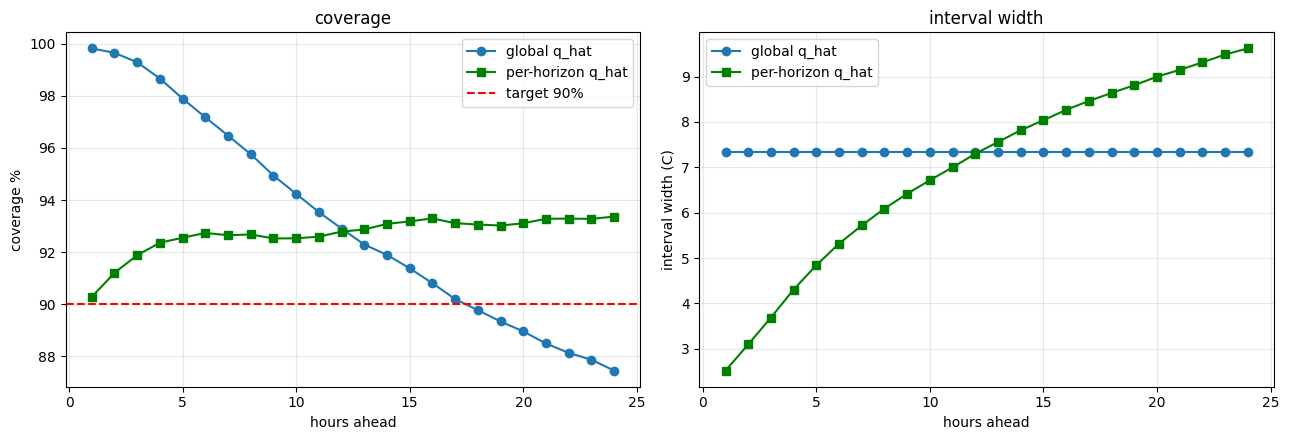

In [11]:
# compare the two approaches side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(hd['horizon'], hd['coverage_pct'], marker='o', label='global q_hat')
ax1.plot(hd2['horizon'], hd2['coverage_pct'], marker='s', color='green', label='per-horizon q_hat')
ax1.axhline(90, color='red', linestyle='--', label='target 90%')
ax1.set_xlabel('hours ahead')
ax1.set_ylabel('coverage %')
ax1.set_title('coverage')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(hd['horizon'], hd['avg_width'], marker='o', label='global q_hat')
ax2.plot(hd2['horizon'], hd2['avg_width'], marker='s', color='green', label='per-horizon q_hat')
ax2.set_xlabel('hours ahead')
ax2.set_ylabel('interval width (C)')
ax2.set_title('interval width')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS, 'conformal_' + MODEL + '_per_horizon_comparison.png'), dpi=150)
plt.show()

# the per-horizon version should hug the 90% line across all horizons
# and use narrower intervals at short lead times - better for the dissertation